# MINI PROJETO - ANÁLISE DE DADOS COM PYTHON | MÓDULO 1
**Felipe Busarello**  
**Curso:** Análise de Dados com Python  
**Turma:** 05 - 2026  
**Professor:** Cláudio Neves

## ACESSAR O ARQUIVO BASE DE DADOS
* Acesse o link https://www.kaggle.com/datasets/namespaiva/base-varejo/data
* Faça o download do arquivo base-varejo.zip
* Instalar as bibliotecas Pandas e Numpy, auxiliares ao Python

## INSTALAÇÕES DAS BIBLIOTECAS UTILIZADAS
As bibliotecas utilizadas no projeto são:  
- **Pandas:** MANIPULAÇÃO E ANÁLISE DE DADOS  
- **Numpy:** CÁLCULOS E OPERAÇÕES NUMÉRICAS  
- **Matplotlib:** CRIAÇÃO DE GRÁFICOS  
- **Seaborn:** VISUALIZAÇÕES ESTATÍSTICAS

In [1]:
%pip install -q pandas
%pip install -q numpy
%pip install -q matplotlib
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## IMPORTAÇÃO DAS BIBLIOTECAS UTILIZADAS

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import csv
from IPython.display import display


# ===========
# VALIDAÇÃO DAS IMPORTAÇÕES E VERSÕES INSTALADAS
# ===========
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Pandas: 3.0.5
NumPy: 2.5.1
Matplotlib: 3.11.1


## LEITURA ARQUIVO BASE

In [3]:
with open("dataset/Base Varejo.csv", encoding="utf-8") as arquivo:
    leitor = csv.DictReader(arquivo)
    colunas = leitor.fieldnames
    vendas = list(leitor)


# ===========
# CONFERÊNCIA DA LEITURA
# ===========
print("VALIDAÇÃO LEITURA ARQUIVO .CSV\n")
print(f"Arquivo lido com sucesso!")
print(f"Quantidade de registros: {len(vendas)}")
print(f"Quantidade de colunas: {len(colunas)}")
print("Colunas:", colunas)
print("\nPrimeiro registro:")
print(vendas[0])

VALIDAÇÃO LEITURA ARQUIVO .CSV

Arquivo lido com sucesso!
Quantidade de registros: 830000
Quantidade de colunas: 1
Colunas: ['DATA;CO_ID;CL_ID;CL_GENERO;CL_EC;CL_FHL;CL_SEG;PR_ID;PR_CAT;PR_NOME;;;;']

Primeiro registro:
{'DATA;CO_ID;CL_ID;CL_GENERO;CL_EC;CL_FHL;CL_SEG;PR_ID;PR_CAT;PR_NOME;;;;': '01/02/2019;1000;534;M;4;1;C;67;BEBIDAS;REFRIGERANTE GUARANA;;;;'}


## Primeira validação
Com a primeira validação, é possível verificar que o `DictReader` está lendo o arquivo, porém está entendendo que a linha inteira é uma única coluna:
```
print(f"Quantidade de colunas: {len(colunas)}")
Quantidade de colunas: 1
```
Isso ocorre, pois o CSV está separando as informações com `;` e não `,` (O padrão de leitura do código `DictReader` é `,`).  
Dessa forma, é necessário informar ao `DictReader` que o limitador dessa base é `;`.

In [4]:
with open("dataset/Base Varejo.csv", encoding="utf-8") as arquivo:
    leitor = csv.DictReader(arquivo, delimiter=";") # INCLUIDO DELIMITADOR ";"
    colunas = leitor.fieldnames
    vendas = list(leitor)


# ===========
# NOVA CONFERÊNCIA DA LEITURA
# ===========
print("VALIDAÇÃO LEITURA ARQUIVO .CSV\n")
print(f"Arquivo lido com sucesso!")
print(f"Quantidade de registros: {len(vendas)}")
print(f"Quantidade de colunas: {len(colunas)}")
print("Colunas:", colunas)
print("\nPrimeiro registro:")
print(vendas[0])

VALIDAÇÃO LEITURA ARQUIVO .CSV

Arquivo lido com sucesso!
Quantidade de registros: 830000
Quantidade de colunas: 14
Colunas: ['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', '', '', '', '']

Primeiro registro:
{'DATA': '01/02/2019', 'CO_ID': '1000', 'CL_ID': '534', 'CL_GENERO': 'M', 'CL_EC': '4', 'CL_FHL': '1', 'CL_SEG': 'C', 'PR_ID': '67', 'PR_CAT': 'BEBIDAS', 'PR_NOME': 'REFRIGERANTE GUARANA', '': ''}


## LEITURA REALIZADA CORRETAMENTE
```
print(f"Quantidade de colunas: {len(colunas)}")
Quantidade de colunas: 14
```

## LEITURA BASE COM A BIBLIOTECA PANDAS

In [5]:
# ===========
# REALIZANDO A LEITURA UTILIZANDO PANDAS
# ===========
df_original = pd.read_csv("dataset/Base Varejo.csv", encoding="utf-8", delimiter=";") # COLOCANDO O DELIMITADOR ';' 
display(df_original.head()) # MOSTRANDO AS 5 PRIMEIRAS LINHAS DO DATAFRAME CRIADO

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


## VALIDAÇÕES INICIAS

In [6]:
print("VISUALIZAÇÕES INICIAIS\n")

# .shape() MOSTRA O NÚMERO DE LINHAS E COLUNAS
print(f"Quantidade de linhas: {df_original.shape[0]}") # MOSTRA O NÚMERO DE LINHAS
print(f"Quantidade de colunas: {df_original.shape[1]}") # MOSTRA O NÚMERO DE COLUNAS

print("\nColunas:")
print(df_original.columns.tolist()) # CRIANDO UMA LISTA COM OS NOMES DA COLUNAS

print("\nPrimeiros 5 registros:")
display(df_original.head())

print("\nÚltimos 5 registros:")
display(df_original.tail())

VISUALIZAÇÕES INICIAIS

Quantidade de linhas: 830000
Quantidade de colunas: 14

Colunas:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Primeiros 5 registros:


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN



Últimos 5 registros:


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
829995,19/08/2022,919822,155,F,2,0,B,183,ALIMENTOS,KETCHUP,NaN,NaN,NaN,NaN
829996,19/08/2022,919822,155,F,2,0,B,56,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN
829997,19/08/2022,919822,155,F,2,0,B,227,ALIMENTOS,ARROZ,NaN,NaN,NaN,NaN
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA,NaN,NaN,NaN,NaN
829999,19/08/2022,919822,155,F,2,0,B,59,ALIMENTOS,SALGADINHO,NaN,NaN,NaN,NaN


Nesse momento foi verifcado que o arquivo base possui 4 (quatro) colunas sem títulos:  
`Unnamed: 10` `Unnamed: 11` `Unnamed: 12` `Unnamed: 13`  
Necessário realizar novas validações para verificar possiveis registros.

## TRATAMENTO COLUNAS SEM TÍTULO

In [7]:
# ===========
# CRIADO O df_columns PARA AS COLUNAS SEM TÍTULO
# ===========
df_columns = df_original[["Unnamed: 10", "Unnamed: 11", "Unnamed: 12", "Unnamed: 13"]]

display(df_columns)

,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
829995,NaN,NaN,NaN,NaN
829996,NaN,NaN,NaN,NaN
829997,NaN,NaN,NaN,NaN
829998,NaN,NaN,NaN,NaN


In [8]:
# ===========
# VERIFICAÇÃO df_columns
# ===========
df_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 10  0 non-null      float64
 1   Unnamed: 11  0 non-null      float64
 2   Unnamed: 12  0 non-null      float64
 3   Unnamed: 13  0 non-null      float64
dtypes: float64(4)
memory usage: 25.3 MB


As colunas não possuem valores preenchidos (`0 non-null`) e, portanto, não apresentam informações úteis para a análise. Elas serão removidas do `df_copia`, preservando o `df_original` para referência.

## CRIANDO df_copia

In [9]:
df_copia = df_original.copy()

# ===========
# REMOVENDO AS COLUNAS SEM INFORMAÇÕES
# ===========
df_copia = df_copia.dropna(axis=1, how="all")

print("Qtd. Colunas antes da limpeza:", df_original.shape)
print("Qtd. Colunas após a limpeza:", df_copia.shape)
print("\nColunas:")
print(df_copia.columns.tolist()) 

Qtd. Colunas antes da limpeza: (830000, 14)
Qtd. Colunas após a limpeza: (830000, 10)

Colunas:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME']


## VALIDAÇÕES DO df_copia

In [10]:
# ===========
# CRIANDO VALIDAÇÕES DO df_copia
# ===========
df_copia.info() # VERIFICANDO AS INFORMAÇÕES DE NULOS E TIPO DE CADA COLUNA
display(df_copia.isnull().sum()) # VALIDANDO O TOTAL DE NULOS DE CADA COLUNA

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   DATA       830000 non-null  str  
 1   CO_ID      830000 non-null  int64
 2   CL_ID      830000 non-null  int64
 3   CL_GENERO  830000 non-null  str  
 4   CL_EC      830000 non-null  int64
 5   CL_FHL     830000 non-null  int64
 6   CL_SEG     830000 non-null  str  
 7   PR_ID      830000 non-null  int64
 8   PR_CAT     830000 non-null  str  
 9   PR_NOME    830000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 63.3 MB


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Após a remoção das colunas totalmente vazias (`Unnamed: 10` a `Unnamed: 13`), a base passou a conter 830.000 registros e 10 colunas, **sem valores nulos**.

## INFORMAÇÕES INCORRETAS NAS COLUNAS

In [11]:
# ===========
# VERIFICANDO TODAS COLUNAS COM INFORMAÇÕES INCORRETAS
# ===========

for coluna in df_copia.columns:
    nulos = df_copia[coluna].isnull().sum()
    espacos = df_copia[coluna].astype(str).str.strip().eq("").sum()
    nd = (df_copia[coluna] == "#N/D").sum()
    
    # VAMOS MOSTRAR APENAS AS COLUNAS QUE POSSUEM ALGUM VALOR INCORETO
    if nulos > 0 or espacos > 0 or nd > 0:
        print(f"\nCOLUNA: {coluna}")

        if nulos > 0:
            print(f"Valores nulos: {nulos}")

        if espacos > 0:
            print(f"Valores apenas com espaços: {espacos}")

        if nd > 0:
            print(f"Valores '#N/D': {nd}")



COLUNA: PR_CAT
Valores '#N/D': 3650

COLUNA: PR_NOME
Valores '#N/D': 3650


As colunas `PR_CAT` e `PR_NOME` apresentam informações preenchidas como `#N/D`. Dessa forma vamos realizar os seguintes tratamentos:  
`PR_CAT` = `#N/D` será substituido por `Sem Categoria`  
`PR_NOME` = `#N/D` será substituido por `Sem Nome`

In [12]:
# ===========
# TRATAMENTO DOS VALORES #N/D
# ===========
df_copia["PR_CAT"] = df_copia["PR_CAT"].replace("#N/D", "Sem Categoria")
df_copia["PR_NOME"] = df_copia["PR_NOME"].replace("#N/D", "Sem Nome")

# ===========
# VALIDAÇÃO DO TRATAMENTO
# ===========
print("PR_CAT - quantidade de #N/D:",
      (df_copia["PR_CAT"] == "#N/D").sum())

print("PR_NOME - quantidade de #N/D:",
      (df_copia["PR_NOME"] == "#N/D").sum())

print("\nPR_CAT - quantidade de 'Sem Categoria':",
      (df_copia["PR_CAT"] == "Sem Categoria").sum())

print("PR_NOME - quantidade de 'Sem Nome':",
      (df_copia["PR_NOME"] == "Sem Nome").sum())

PR_CAT - quantidade de #N/D: 0
PR_NOME - quantidade de #N/D: 0

PR_CAT - quantidade de 'Sem Categoria': 3650
PR_NOME - quantidade de 'Sem Nome': 3650


## DUPLICIDADE

In [13]:
# ===========
# VALIDANDO AS INFORMAÇÕES EM DUPLICIDADE
# ===========
df_copia.duplicated().sum()    # SOMANDO AS LINHAS QUE ESTÃO EM DUPLICIDADE

np.int64(96553)

Foram identificado 96553 linhas em duplicidade.  
Entendendo que, na base não deve ter duplicidade, foram realizado as retirados das linhas duplicadas.

In [14]:
# ===========
# REMOVENDO AS LINHAS EM DUPLICIDADE
# ===========
df_copia = df_copia.drop_duplicates()
print("Qtd. Linhas Duplicadas:", df_copia.duplicated().sum())
print("Qtd. Linhas antes da limpeza:", df_original.shape[0])
print("Qtd. Linhas após a limpeza:", df_copia.shape[0])

Qtd. Linhas Duplicadas: 0
Qtd. Linhas antes da limpeza: 830000
Qtd. Linhas após a limpeza: 733447


Após a remoção das colunas vazias e linhas duplicadas, foi realizado uma análise para verificar o `dtype` de cada coluna e realizado os ajustes necessários.

## AJUSTE TIPO DA COLUNA

In [15]:
# ===========
# VERIFICANDO O TIPO DE CADA COLUNA
# ===========
display(df_copia.dtypes)


DATA           str
CO_ID        int64
CL_ID        int64
CL_GENERO      str
CL_EC        int64
CL_FHL       int64
CL_SEG         str
PR_ID        int64
PR_CAT         str
PR_NOME        str
dtype: object

Verificando que as colunas `CO_ID`, `CL_ID` e `PR_ID` são códigos de indentificação de compras, clientes e produtos, não devem ser considerados números (`int64`) e sim textos (`str`).  
A coluna `DATA` está como texto (`str`), vamos ajustar para o tipo correto `datetime`.  

Necessário realizar as alterações para o `Dtype` corretos.

In [16]:
# ===========
# AJUSTANDO OS TIPOS DAS COLUNAS PARA O FORMATO CORRETO
# ===========
df_copia["CO_ID"] = df_copia["CO_ID"].astype("str")
df_copia["CL_ID"] = df_copia["CL_ID"].astype("str")
df_copia["PR_ID"] = df_copia["PR_ID"].astype("str")

df_copia["DATA"] = pd.to_datetime(
    df_copia["DATA"],
    format="%d/%m/%Y",
    errors="coerce"
)

# ===========
# VALIDANDO AS ALTERAÇÕES REALIZADAS
# ===========
display(df_original[["DATA","CO_ID","CL_ID","PR_ID"]].dtypes)
display(df_copia[["DATA","CO_ID","CL_ID","PR_ID"]].dtypes)



DATA       str
CO_ID    int64
CL_ID    int64
PR_ID    int64
dtype: object

DATA     datetime64[us]
CO_ID               str
CL_ID               str
PR_ID               str
dtype: object

In [17]:
# ===========
# VALIDANDO A COLUNA DATA E POSSÍVEIS DATAS INVÁLIDAS (FORA DO PADRÃO)
# ===========
data_invalidas = df_copia["DATA"].isna().sum()
print(f"Quantidade de datas inválidas: {data_invalidas}")

if data_invalidas == 0:
    print("Não foram identificadas datas inválidas durante a conversão.")
    
# ===========
# VALIDANDO O PERÍODO DAS DATAS
# ===========
print("\nData mais antiga:", df_copia["DATA"].min())
print("Data mais recente:", df_copia["DATA"].max())

Quantidade de datas inválidas: 0
Não foram identificadas datas inválidas durante a conversão.

Data mais antiga: 2019-01-04 00:00:00
Data mais recente: 2022-12-08 00:00:00


## ANÁLISES ESTATÍSTIVAS DESCRITIVAS
SERÁ REALIZADO ANÁLISES INICIAIS NA COLUNA `CL_FHL`

In [18]:
# ===========
# VERIFICANDO AS ESTATÍTICAS BÁSICAS NA COLUNA `CL_FHL` 
# ===========
df_copia["CL_FHL"].describe()

count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64

A FUNÇÃO `.describe()` mostra os seguintes resultados:  

| ESTATÍSTICA | RESULTADO | INTERPRETAÇÃO |
| --------- | --------- | --------- |
| count | 733.447 | EXISTEM 733.447 REGISTROS COM INFORMAÇÃO NA COLUNA `CL_FHL` |
| mean | 1,146 | EM MÉDIA, OS REGISTROS POSSUEM APROXIMADAMTENTE 1,15 FILHOS |
| std/ Desvio Padrão | 1,417 | EXISTE UM DESVIO CONSIDERAVEL EM RELAÇÃO A MÉDIA |
| min | 0 | EXISTEM REGISTROS DE CLIENTES SEM FILHOS |
| 1º Quartil (25%) | 0 | PELO MENOS 25% DOS REGISTROS NÃO POSSUEM FILHOS |
| Mediana (50%) | 0 | METADO DOS REGISTROS NÃO POSSUEM FILHOS |
| 3º Quartil (75%) | 2 | 75% DOS REGISTROS POSSUEM ATÉ 2 FILHOS |
| max | 4 | O MAIOR NÚMERO DE FILHOS É 4 |

ALÉM DAS INFORMAÇÕES DO `.describe()` TAMBÉM VAMOS REALIZAR O CALCULO DA MODA PARA VERIFICAR O VALOR QUE APARECE COM MAIOR FREQUENCIA NA COLUNA `CL_FHL`

In [19]:
# ===========
# CÁLCULANDO A MODA
# ===========
moda = df_copia["CL_FHL"].mode()

print("Moda:", moda.iloc[0])

Moda: 0


ASSIM COMO A FUNÇÃO `.describe()` MOSTROU, A MEDIANA (50%) DOS REGISTROS NÃO POSSUEM FILHOS (0), A MODA CONFIRMOU ISSO.

In [20]:
# ===========
# AVALIANDO A DISTRIBUIÇÃO DE FILHOS
# ===========
distribuicao_filhos = (df_copia["CL_FHL"].value_counts().sort_index().to_frame(name="Quantidade"))
distribuicao_filhos["Percentual"] = (distribuicao_filhos["Quantidade"] / distribuicao_filhos["Quantidade"].sum()* 100)
distribuicao_filhos["Percentual"] = (distribuicao_filhos["Percentual"].map(lambda x: f"{x:.2f}%"))

display(distribuicao_filhos)

,Quantidade,Percentual
CL_FHL,,
0,384986,52.49%
1,90845,12.39%
2,94168,12.84%
3,92407,12.60%
4,71041,9.69%


## INSIGHT:
1. ASSIM COMO A `MODA` E `MEDIANA`, A DISTRIBUIÇÃO EM PERCENTUAL MOSTRO QUE `52,49%` DOS REGISTROS NÃO POSSUEM FILHOS;
2. RETIRANDO OS CLIENTES SEM FILHO (52,49%), A DISTRIBUIÇÃO DOS CLIENTES COM 1 ATÉ 4 FILHOS ESTÁ EQUILIBRADA, MANTENDO QUASE IGUAL NOS CLIENTES COM 1 ATÉ 3 FILHOS;
3. POSSÍVEL VERIFICAR QUE OS CLIENTES SEM FILHO, COM 1 E 2 FILHOS REPRESENTAM QUASE 78%, OU SEJA 3º QUARTIL APRESENTADO ANTERIORMENTE.  
  
OBS: COMO O df_copia NÃO INFORMA SE CADA REGISTRO REPRESENTA 1 CLIENTE, OU SE O CLIENTE PODE REPETIR VÁRIAS VEZES, É NECESSÁRIO FAZER ESSA VERIFICAÇÃO PARA GARANTIR QUE OS INSIGHT A CIMA SÃO POR CLIENTE OU POR VENDA

In [21]:
# ===========
# AVALIANDO DE CLIENTES ÚNICOS
# ===========
clientes_unicos = df_copia["CL_ID"].nunique()

print(f"Total de registro: {len(df_copia)}")
print(f"Total de clientes únicos: {clientes_unicos}")
if clientes_unicos != len(df_copia):
    print("Existem clientes com mais de um registro na base.")

Total de registro: 733447
Total de clientes únicos: 1000
Existem clientes com mais de um registro na base.


In [22]:
# ===========
# CONTABILIZANDO A FREQUENCIA POR `CL_ID`
# ===========
frequencia_clientes = df_copia["CL_ID"].value_counts()
display(frequencia_clientes.head(5))

CL_ID
822    1532
485    1433
397    1342
369    1334
971    1315
Name: count, dtype: int64

CONFORME INFORMADO ANTERIORMENTE, A BASE MOSTRA A FREQUÊNCIA DE COMPRA DOS CLIENTES, DESSA FORMA O CLIENTE PODE REPETIR DIVERSAS VEZES.  
EXEMPLO O CLIENTE `CL_ID` 822 QUE POSSUI UMA FREQUENCIA DE 1.532 COMPRAS.

## ANÁLISE DOS REGISTRO POR ANO/MÊS

In [23]:
# ===========
# EVOLUÇÃO TEMPORAL DOS REGISTROS
# ===========
df_copia["ANO"] = df_copia["DATA"].dt.year # CRIANDO A COLUNA ANO
df_copia["MES"] = df_copia["DATA"].dt.month # CRIANDO A COLUNA MÊS
df_copia["PERIODO"] = df_copia["DATA"].dt.strftime("%m/%Y") # CRIANDO A COLUNA PERIODO (MÊS/ANP)


# ===========
# EVOLUÇÃO MÊS/ANO
# ===========
registros_mes = (df_copia.groupby(["PERIODO"]).size().reset_index(name="Quantidade"))
registros_mes["Percentual"] = (registros_mes["Quantidade"] / registros_mes["Quantidade"].sum() * 100)
registros_mes["Percentual"] = (registros_mes["Percentual"].map(lambda x: f"{x:.2f}%"))

melhores_5_meses = (registros_mes.sort_values("Quantidade", ascending=False).head(5))
print("Top 5 Melhores Mês/Ano")
display(melhores_5_meses)

piores_5_meses = (registros_mes.sort_values("Quantidade", ascending=True).head(5))
print("\nTop 5 Piores Mês/Ano")
display(piores_5_meses)


# ===========
# EVOLUÇÃO ANO
# ===========
registros_ano = (df_copia.groupby(["ANO"]).size().reset_index(name="Quantidade"))
registros_ano["Percentual"] = (registros_ano["Quantidade"] / registros_ano["Quantidade"].sum() * 100)
registros_ano["Percentual"] = (registros_ano["Percentual"].map(lambda x: f"{x:.2f}%"))

print("\nEvolução por Ano")
display(registros_ano)


Top 5 Melhores Mês/Ano


,PERIODO,Quantidade,Percentual
38,10/2021,28575,3.90%
16,05/2019,28115,3.83%
37,10/2020,25275,3.45%
2,01/2021,23915,3.26%
26,07/2021,23635,3.22%



Top 5 Piores Mês/Ano


,PERIODO,Quantidade,Percentual
35,09/2022,1297,0.18%
39,10/2022,2373,0.32%
40,11/2019,6120,0.83%
43,11/2022,6192,0.84%
0,01/2019,6492,0.89%



Evolução por Ano


,ANO,Quantidade,Percentual
0,2019,176103,24.01%
1,2020,192804,26.29%
2,2021,216813,29.56%
3,2022,147727,20.14%


## INSIGHT:
1. É POSSÍVEL VERIFICAR UM CRESCIMENTO CONTINUO NO VOLUME DE REGISTRO DE 2019 ATÉ 2021.
2. FORTE REDUÇÃO NO VOLUME DE REGISTROS EM 2022.
3. OS MAIORES VOLUMES DE REGISTROS ESTÃO CONCENTRADOS NO ANO DE 2021, SENDO ESSE ANO O ANO COM MAIOR VOLUME DE REGISTRO.

## ANÁLISE DISTRIBUIÇÃO POR CATEGORIA

In [24]:
# ===========
# AVALIANDO A DISTRIBUIÇÃO DE REGISTRO POR CATEGORIA DE PRODUTO
# ===========
distribuicao_categoria = (df_copia["PR_CAT"].value_counts().sort_index().to_frame(name="Quantidade"))
distribuicao_categoria["Percentual"] = (distribuicao_categoria["Quantidade"] / distribuicao_categoria["Quantidade"].sum()* 100)
distribuicao_categoria["Percentual"] = (distribuicao_categoria["Percentual"].map(lambda x: f"{x:.2f}%"))
distribuicao_categoria = (distribuicao_categoria.sort_values("Quantidade", ascending=False))

display(distribuicao_categoria)

,Quantidade,Percentual
PR_CAT,,
ALIMENTOS,384197,52.38%
HIGIENE,137702,18.77%
LIMPEZA,128632,17.54%
BEBIDAS,38264,5.22%
PET,28553,3.89%
ACESSORIOS,12871,1.75%
Sem Categoria,3228,0.44%


## INSIGHT:
1. A CATEGORIA `ALIMENTOS` REPRESENTA 52% DO TOTAL DOS REGISTROS.
2. AS CATEGORIAS `HIGIENE` E `LIMPEZA` REPRESENTAM MAIS DE 30% DO TOTAL DOS REGISTROS.
3. AS CATEGORIAS `ALIMENTOS`, `HIGIENE` E `LIMPEZA` JUNTOS REPRESENTAM 88% DOS REGISTROS. MOSTRANDO FORTE CONCENTRAÇÃO NESSAS CATEGORIAS.
4. AS DEMAIS CATEGORIAS REPRESENTAM APENAS 10% DO TOTAL DOS REGISTRANDO, MOSTRANDO MENOR PARTICIPAÇÃO.
5. OS REGISTROS `SEM CATEGORIA` REPRESENTAM MENOS DE 1%, MOSTRANDO QUE A MAIOR PARTE DOS REGISTRO POSSUEM CATEGORIA DE PRODUTO.

## DISTRIBUIÇÃO DE FILHOS POR CATEGORIA DE PRODUTO

In [25]:
# ===========
# NÚMERO DE FILHOS × CATEGORIA DE PRODUTO
# ===========
filhos_categoria = (df_copia.groupby(["CL_FHL", "PR_CAT"]).size().reset_index(name="Quantidade"))

# CALCULANDO O PERCENTUAL DE CADA GRUPO DE FILHOS
filhos_categoria["Percentual"] = (filhos_categoria["Quantidade"] / filhos_categoria.groupby("CL_FHL")["Quantidade"].transform("sum")* 100)
filhos_categoria["Percentual"] = (filhos_categoria["Percentual"].map(lambda x: f"{x:.2f}%"))
filhos_categoria = filhos_categoria.sort_values(["CL_FHL", "Quantidade"],ascending=[True, False])
# display(filhos_categoria) ## COMO A TABELA FICA MUITO EXTENSA, VAMOS ALTERAR PARA VISUALIZAÇÃO UTILIZANDO pivot_table()


# ===========
# UTILIZANDO pivot_table()
# ===========
pivot_filhos_categoria = pd.pivot_table(df_copia,index="CL_FHL",columns="PR_CAT",aggfunc="size",fill_value=0)
print("Quantidade de Registro")
display(pivot_filhos_categoria)

pivot_filhos_categoria_percentual = (pivot_filhos_categoria.div(pivot_filhos_categoria.sum(axis=1), axis=0) * 100)
print("Percentual de Registro")
display(pivot_filhos_categoria_percentual.round(2))

Quantidade de Registro


PR_CAT,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET,Sem Categoria
CL_FHL,,,,,,,
0,6755,201670,19991,72302,67625,14960,1683
1,1564,47613,4901,17018,15782,3561,406
2,1647,49269,4895,17647,16583,3721,406
3,1689,48284,4812,17487,16148,3587,400
4,1216,37361,3665,13248,12494,2724,333


Percentual de Registro


PR_CAT,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET,Sem Categoria
CL_FHL,,,,,,,
0,1.75,52.38,5.19,18.78,17.57,3.89,0.44
1,1.72,52.41,5.39,18.73,17.37,3.92,0.45
2,1.75,52.32,5.20,18.74,17.61,3.95,0.43
3,1.83,52.25,5.21,18.92,17.47,3.88,0.43
4,1.71,52.59,5.16,18.65,17.59,3.83,0.47


## INSIGHT
1. A CATEGORIA `ALIMENTOS` É A PRINCIPAL CATEGORIA INDEPENDENTE DO NÚMERO DE FILHOS, NÃO MOSTRANDO DIFERENÇA RELEVANTES ENTRE ELES.
2. O NÚMERO DE FILHOS NÃO PARECE ESTAR ASSOCIADO A MUDANÇAS RELEVANTES NA DISTRIBUIÇÃO DAS CATEGORIAS.

## FILHOS POR SEGMENTO ECONÔMICO

In [26]:
# ===========
# NÚMERO DE FILHOS × SEGMENTO ECONÔMICO
# ===========
filhos_segmento = (df_copia.groupby(["CL_FHL", "CL_SEG"]).size().reset_index(name="Quantidade"))

# CALCULANDO O PERCUNTAL DE CADA GRUPO DE FILHOS
filhos_segmento["Percentual"] = (filhos_segmento["Quantidade"] / filhos_segmento.groupby("CL_FHL")["Quantidade"].transform("sum")* 100)
filhos_segmento["Percentual"] = (filhos_segmento["Percentual"].map(lambda x: f"{x:.2f}%"))
filhos_segmento = filhos_segmento.sort_values(["CL_FHL", "Quantidade"],ascending=[True, False])
#display(filhos_segmento) ## COMO A TABELA FICA MUITO EXTENSA, VAMOS ALTERAR PARA VISUALIZAÇÃO UTILIZANDO pivot_table()


# ===========
# UTILIZANDO pivot_table()
# ===========
pivot_filhos_segmento = pd.pivot_table(df_copia,index="CL_FHL",columns="CL_SEG",aggfunc="size",fill_value=0)
print("Quantidade de Registro")
display(pivot_filhos_segmento)

pivot_filhos_segmento_percentual = (pivot_filhos_segmento.div(pivot_filhos_segmento.sum(axis=1), axis=0) * 100)
print("Percentual de Registro")
display(pivot_filhos_segmento_percentual.round(2))

Quantidade de Registro


CL_SEG,A,B,C
CL_FHL,,,
0,31598,246672,106716
1,8693,57237,24915
2,8682,56793,28693
3,6828,64791,20788
4,3876,43012,24153


Percentual de Registro


CL_SEG,A,B,C
CL_FHL,,,
0,8.21,64.07,27.72
1,9.57,63.01,27.43
2,9.22,60.31,30.47
3,7.39,70.11,22.50
4,5.46,60.55,34.00


## INSIGHT
1. O SEGMENTO `B` CONCENTRA A MAIOR PARTE DOS REGISTROS, INDEPENDENTEMENTE DO NÚMERO DE FILHOS.
2. O SEGMENTO `C` POSSUI MAIOR CONCENTRAÇÃO NOS REGISTRO COM 4 FILHOS.
3. O SEGMENTO `A` POSSUI MENOR REPRESENTAÇÃO EM TODOS OS GRUPOS, VARIANDO DE 5,46% ATÉ 9,57%.

## GÊNERO POR CATEGORIA DE PRODUTO

In [27]:
# ===========
# GÊNERO × CATEGORIA DE PRODUTO
# ===========
genero_categoria = (df_copia.groupby(["CL_GENERO", "PR_CAT"]).size().reset_index(name="Quantidade"))
genero_categoria["Percentual"] = (genero_categoria["Quantidade"] / genero_categoria.groupby("CL_GENERO")["Quantidade"].transform("sum")* 100)
genero_categoria["Percentual"] = (genero_categoria["Percentual"].map(lambda x: f"{x:.2f}%"))
genero_categoria = genero_categoria.sort_values(["CL_GENERO", "Quantidade"],ascending=[True, False])
# display(genero_categoria) ## COMO A TABELA FICA MUITO EXTENSA, VAMOS ALTERAR PARA VISUALIZAÇÃO UTILIZANDO pivot_table()


# ===========
# UTILIZANDO pivot_table()
# ===========
pivot_genero_categoria = pd.pivot_table(df_copia,index="CL_GENERO",columns="PR_CAT",aggfunc="size",fill_value=0)
print("Quantidade de Registro")
display(pivot_genero_categoria)

pivot_genero_categoria_percentual = (pivot_genero_categoria.div(pivot_genero_categoria.sum(axis=1), axis=0) * 100)
print("Percentual de Registro")
display(pivot_genero_categoria_percentual.round(2))

Quantidade de Registro


PR_CAT,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET,Sem Categoria
CL_GENERO,,,,,,,
F,6839,200274,19764,71721,67328,14809,1692
M,6032,183923,18500,65981,61304,13744,1536


Percentual de Registro


PR_CAT,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET,Sem Categoria
CL_GENERO,,,,,,,
F,1.79,52.37,5.17,18.75,17.61,3.87,0.44
M,1.72,52.40,5.27,18.80,17.46,3.92,0.44


## INSIGHT
1. MANTENDO A MESMA DISTRIBUIÇÃO DOS REGISTRO, TANTO PARA O GÊNERO `F` E `M` A CATEGORIA `ALIMENTO` É A PRINCIPAL CATEGORIA DOS REGISTROS.
2. NÃO EXISTE DIFERENÇA RELEVANTES ENTRE OS REGISTRO DOS GÊNEROS. AS VARIAÇÕES SÃO PEQUENAS, INDICANTO QUE O GÊNERO NÃO CAUSA ALTERAÇÃO NOS REGISTROS.

# GRÁFICOS

## GRÁFICO 1 - EVOLUÇÃO DOS REGISTROS POR ANO

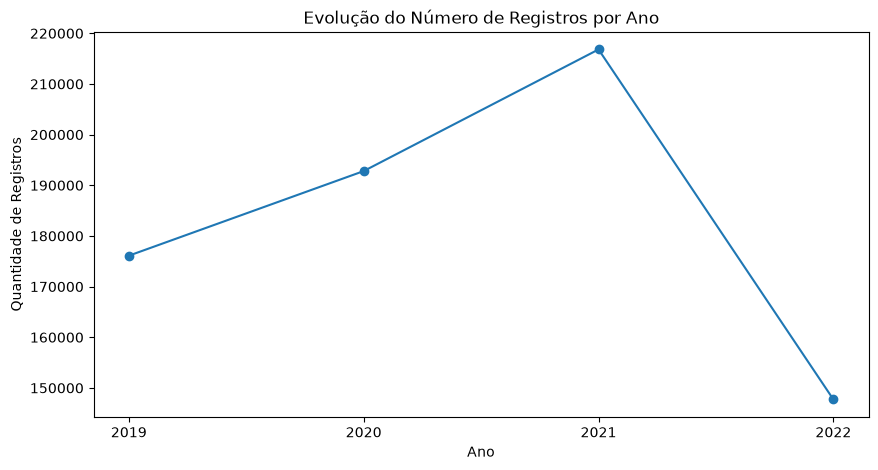

In [28]:
# ===========
# EVOLUÇÃO DOS REGISTROS POR ANO
# ===========
registros_ano_grafico = (df_copia.groupby("ANO").size().reset_index(name="Quantidade"))

plt.figure(figsize=(10, 5))
plt.plot(registros_ano_grafico["ANO"],registros_ano_grafico["Quantidade"],marker="o")
plt.title("Evolução do Número de Registros por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Registros")
plt.xticks(registros_ano_grafico["ANO"])
plt.savefig("Graficos/grafico1_evolucao_registros_ano.png",dpi=300,bbox_inches="tight")
plt.show()

GRÁFICO 1 MOSTRA:
* CRESCIMENTO DE 2019 ATÉ 2021.
* MAIOR NÚMERO DE REGISTRO EM 2021.
* QUEDA BRUSCA EM 2022.

## GRÁFICO 2 - DISTRIBUIÇÃO POR CATEGORIA

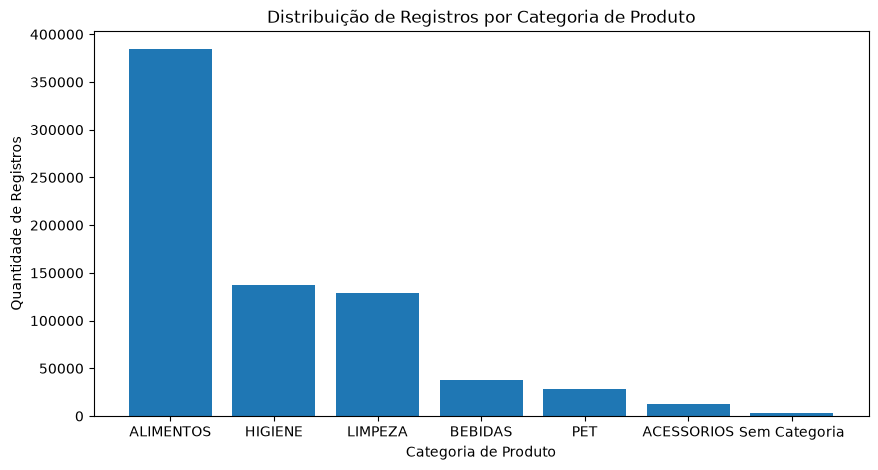

In [29]:
# ===========
# DISTRIBUIÇÃO POR CATEGORIA
# ===========
plt.figure(figsize=(10, 5))
plt.bar(distribuicao_categoria.index,distribuicao_categoria["Quantidade"])
plt.title("Distribuição de Registros por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Quantidade de Registros")
plt.savefig("Graficos/grafico2_registro_por_categoria_produto.png",dpi=300,bbox_inches="tight")
plt.show()

GRÁFICO 2 MOSTRA:
* `ALIMENTOS`REPRESENTAM MAIOR VOLUME DE REGISTRO. MAIS QUE O DOBRO DO SEGUNDO SEGMENTO.
* `HIGIENE` E `LIMPEZA` POSSUEM QUASE O MESMO NÚMERO DE REGISTRO.
* `SEM CATEGORIA` NÃO POSSUI VALOR SIGNIFICATIVO.

## GRÁFICO 3 - DISTRIBUIÇÃO DO NÚMERO DE FILHOS

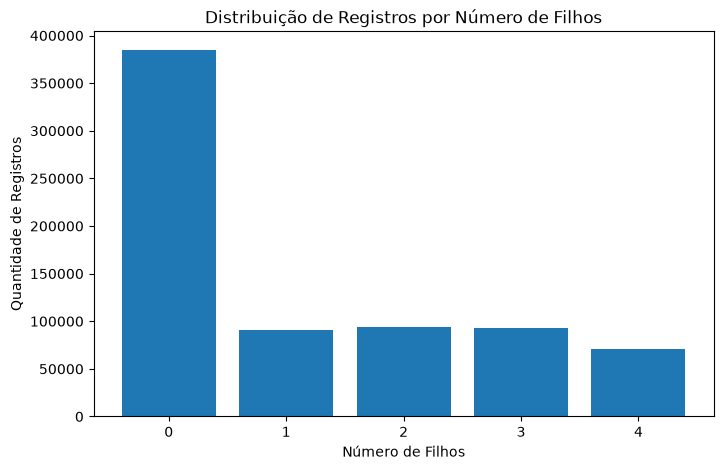

In [30]:
# ===========
# GRÁFICO 3 - DISTRIBUIÇÃO DO NÚMERO DE FILHOS
# ===========
distribuicao_filhos = (df_copia["CL_FHL"].value_counts().sort_index())
plt.figure(figsize=(8, 5))
plt.bar(distribuicao_filhos.index.astype(str),distribuicao_filhos.values)
plt.title("Distribuição de Registros por Número de Filhos")
plt.xlabel("Número de Filhos")
plt.ylabel("Quantidade de Registros")
plt.savefig("Graficos/grafico3_registros_por_filho.png",dpi=300,bbox_inches="tight")
plt.show()

GRÁFICO 3 MOSTRA:
* SEM FILHOS POSSUI O MAIOR VALUME DE REGISTRO.
* EQUILIBRIO NO NÚMERO DE REGISTRO DOS CLIENTES COM 1 ATÉ 4 FILHOS.

## GRÁFICO 4 - FILHOS x SEGMENTO ECONÔMICO

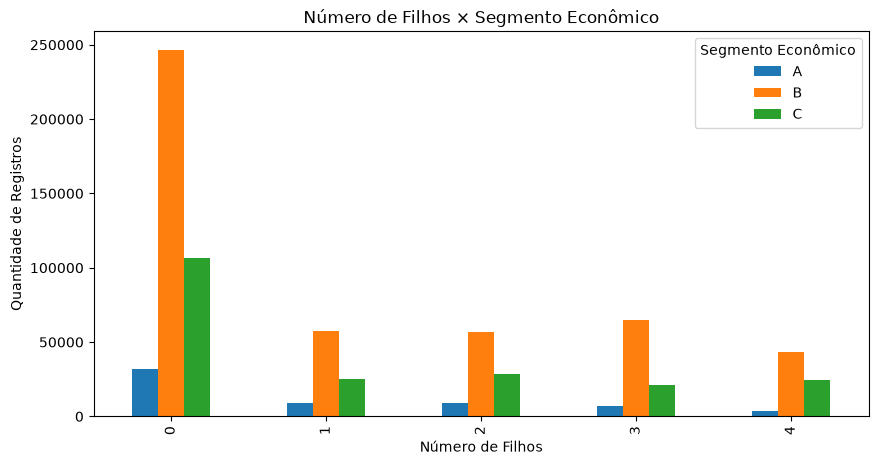

In [31]:
# ===========
# GRÁFICO 4 - FILHOS × SEGMENTO ECONÔMICO
# ===========
pivot_filhos_segmento = pd.pivot_table(df_copia,index="CL_FHL",columns="CL_SEG",aggfunc="size",fill_value=0)
pivot_filhos_segmento.plot(kind="bar",figsize=(10, 5))

plt.title("Número de Filhos × Segmento Econômico")
plt.xlabel("Número de Filhos")
plt.ylabel("Quantidade de Registros")
plt.legend(title="Segmento Econômico")
plt.savefig("Graficos/grafico4_filhos_segmento_economico.png",dpi=300,bbox_inches="tight")
plt.show()

GRÁFICO 4 MOSTRA:
* MAIOR VOLUMETRIA PARA O SEGMENTO ECONOMICO `B`, EM QUALQUER GRUPO DE FILHOS.

## GRÁFICO 5 - EVOLUÇÃO DOS REGISTROS POR MÊS/ANO

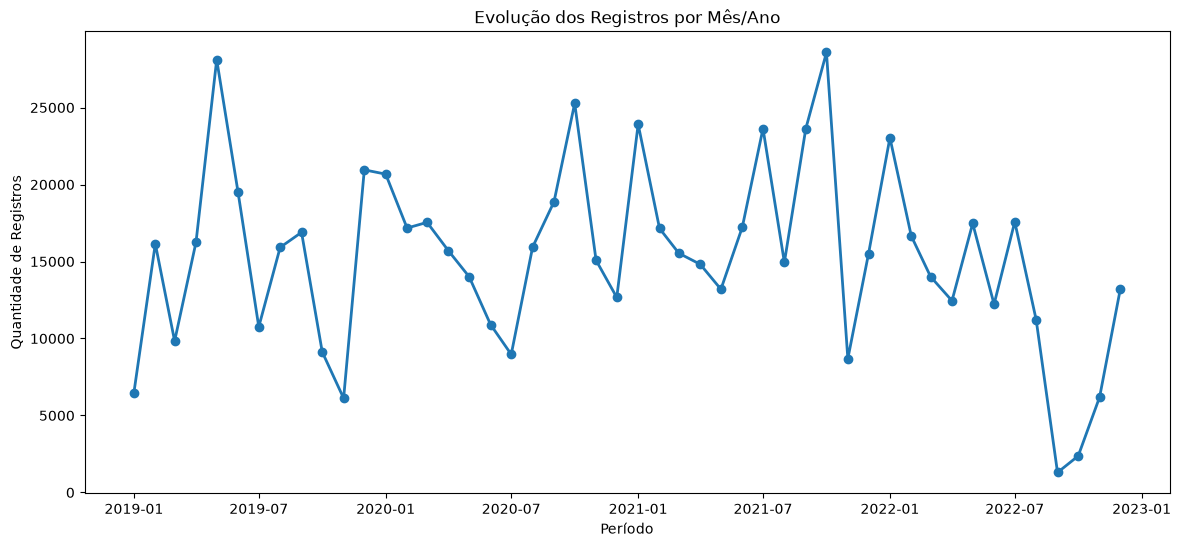

In [32]:
# ===========
# EVOLUÇÃO DOS REGISTROS POR MÊSANO
# ===========
registros_mes = (df_copia.set_index("DATA").resample("MS").size().reset_index(name="Quantidade"))

plt.figure(figsize=(14, 6))
plt.plot(registros_mes["DATA"],registros_mes["Quantidade"],marker="o",linewidth=2)
plt.title("Evolução dos Registros por Mês/Ano")
plt.xlabel("Período")
plt.ylabel("Quantidade de Registros")
plt.savefig("Graficos/grafico5_evolucao_registros_mes_ano.png",dpi=300,bbox_inches="tight")
plt.show()

## GRÁFICO 5 - DISTRIBUIÇÃO POR GÊNERO

CL_GENERO
F    382427
M    351020
Name: count, dtype: int64

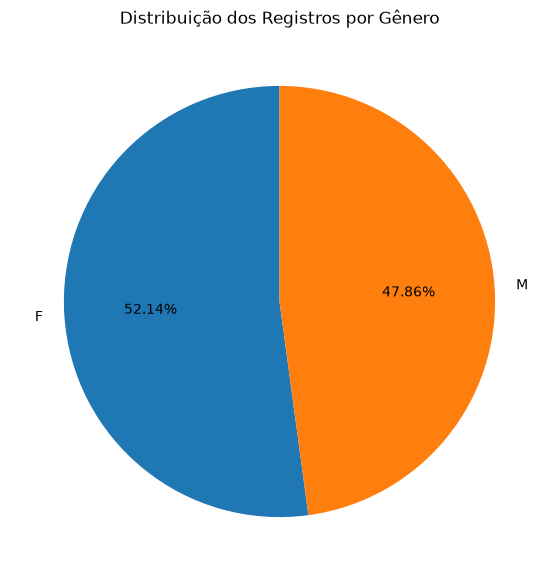

In [33]:
# ===========
# CRIANDO A DISTRIBUIÇÃO
# ===========
distribuicao_genero = (df_copia["CL_GENERO"].value_counts())
display(distribuicao_genero)

# ===========
# CRIANDO O GRÁFICO
# ===========
plt.figure(figsize=(7, 7))
plt.pie(distribuicao_genero,labels=distribuicao_genero.index,autopct="%1.2f%%",startangle=90)
plt.title("Distribuição dos Registros por Gênero")
plt.savefig("Graficos/grafico6_distribuicao_registros_genero.png",dpi=300,bbox_inches="tight")
plt.show()

## GRÁFICO 7 - TOP PRODUTOS POR SEGMENTO

PR_NOME
PRESUNTO COZIDO    12719
SARDINHA            6610
BANANA              6518
ESCOVA DE DENTE     6518
GEL                 6517
Name: count, dtype: int64

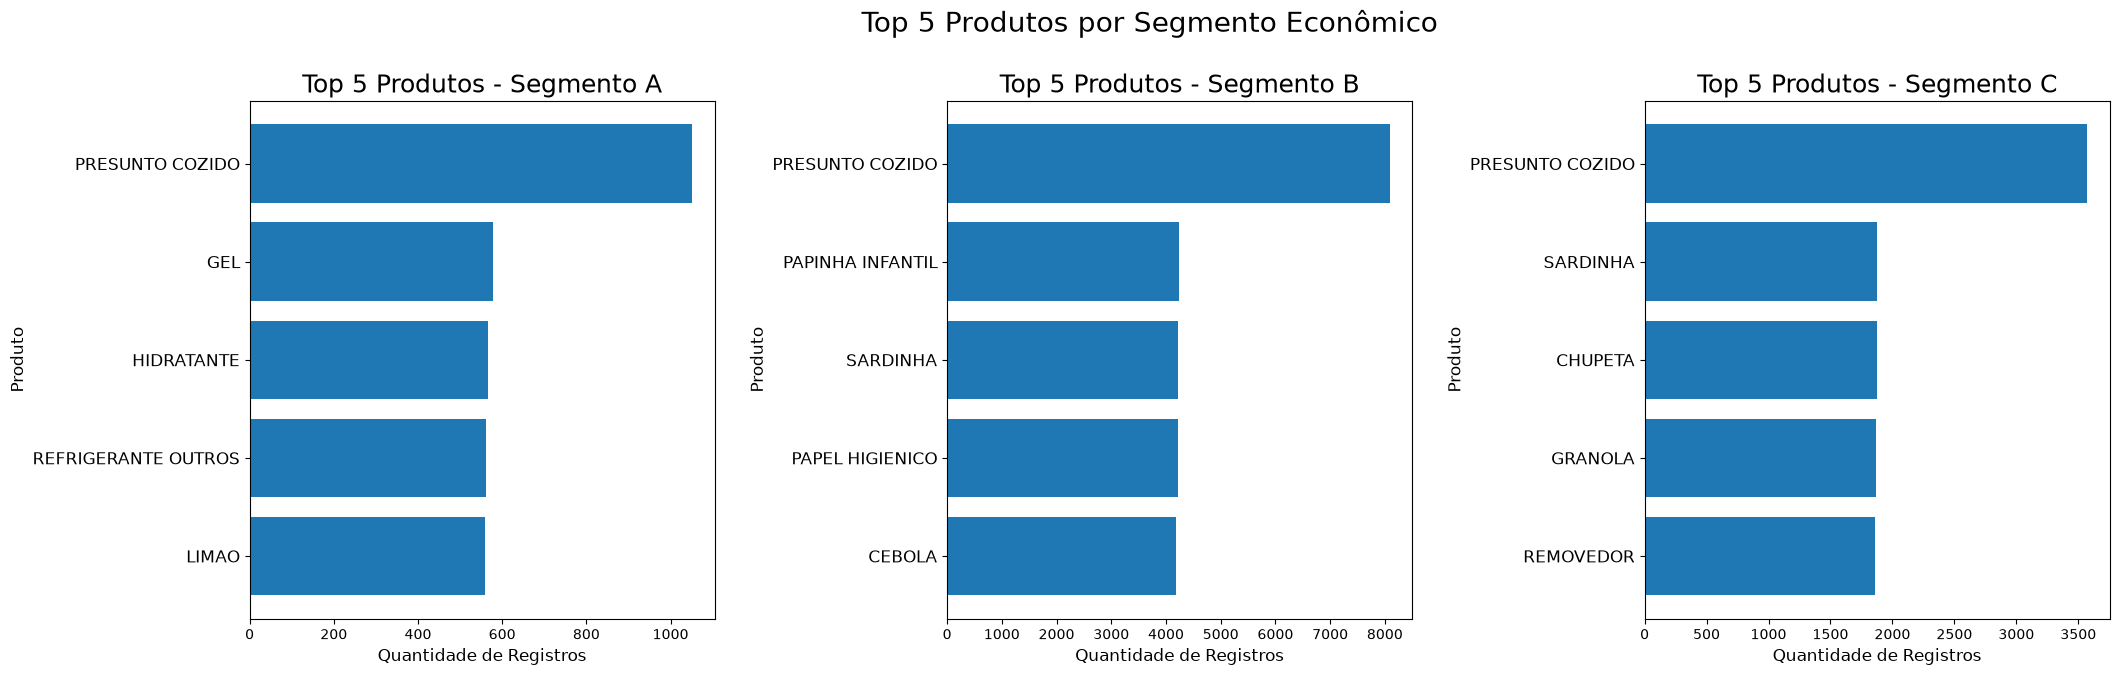

In [34]:
# ===========
# TOP 5 PRODUTOS COM MAIORES REGISTROS
# ===========
top_produtos = df_copia["PR_NOME"].value_counts().head(5)
display(top_produtos)


# ===========
# CRIANDO GRÁFICO POR SEGMENTO
# ===========
segmentos = sorted(df_copia["CL_SEG"].unique())
fig, axes = plt.subplots(1,3,figsize=(24, 7))
axes = axes.flatten()

for i, segmento in enumerate(segmentos):
    df_segmento = df_copia[df_copia["CL_SEG"] == segmento]
    top_produtos = (df_segmento["PR_NOME"].value_counts().head(5).sort_values(ascending=True))
    axes[i].barh(top_produtos.index,top_produtos.values)
    axes[i].set_title(f"Top 5 Produtos - Segmento {segmento}",fontsize=18)
    axes[i].set_xlabel("Quantidade de Registros", fontsize=12)
    axes[i].set_ylabel("Produto", fontsize=12)
    axes[i].tick_params(axis="y",labelsize=12)

plt.suptitle("Top 5 Produtos por Segmento Econômico",fontsize=20)
plt.subplots_adjust(wspace=0.5,top=0.85)
plt.savefig("Graficos/grafico7_top5_produtos_segmento_economico.png",dpi=300,bbox_inches="tight")
plt.show()

## CRIANDO df_final

In [35]:
# ===========
# CRIANDO df_final
# ===========
df_final = df_copia.copy()
df_final = df_final.drop(columns=["ANO", "MES", "PERIODO"],errors="ignore") # EXLUINDO COLUNAS CRIADAS PARA AS ANÁLISES
display(df_final)

# ===========
# SALVANDO 
# ===========
df_final.to_csv("dataset/df_final.csv",index=False,encoding="utf-8-sig")
print("Arquivo df_final.csv criado com sucesso!")
print(f"Quantidade de registros: {len(df_final)}")
print(f"Quantidade de colunas: {len(df_final.columns)}")

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO
...,...,...,...,...,...,...,...,...,...,...
829991,2022-08-19,919822,155,F,2,0,B,86,HIGIENE,PRESERVATIVO
829993,2022-08-19,919822,155,F,2,0,B,62,ALIMENTOS,SNACKS
829994,2022-08-19,919822,155,F,2,0,B,11,ALIMENTOS,AZEITE
829998,2022-08-19,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA


Arquivo df_final.csv criado com sucesso!
Quantidade de registros: 733447
Quantidade de colunas: 10


In [36]:
# ===========
# VALIDAÇÃO DO ARQUIVO FINAL
# ===========
display(df_final.head())

print("\nDimensões:")
print(df_final.shape)

print("\nTipos de dados:")
display(df_final.dtypes)

print("\nValores nulos:")
display(df_final.isnull().sum())

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO



Dimensões:
(733447, 10)

Tipos de dados:


DATA         datetime64[us]
CO_ID                   str
CL_ID                   str
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                   str
PR_CAT                  str
PR_NOME                 str
dtype: object


Valores nulos:


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

# CONCLUSÃO - ANÁLISE FINAL
APÓS AS ETAPAS DE TRATAMENTO, LIMPEZA E ANÁLISE EXPLORATÓRIA DOS DADOS, FOI POSSÍVEL IDENTIFICAR:
* O ARQUIVO `Base Varejo` APRESENTAVA **4 COLUNAS COMPLETAMENTE VAZIAS**, ESSA FORAM REMOVIDAS POR NÃO SEREM UTÉIS PARA AS ANÁLISES;
* FORAM IDENTIFICADOS E REMOVIDOS **96.553 REGISTROS DUPLICADOS**;
* O PERÍODO ANALISADO FOI **JANEIRO DE 2019 A DEZEMBRO DE 2022**;
* **2021 POSSUI O MAIOR VOLUME DE REGISTRO** E **2022 O MENOR VOLUME**;
* **SEGMENTO B** POSSUI O MAIOR VOLUME DE REGISTROS;
* GÊNERO **f** APRESENTOU VOLUME MAIOR DE REGISTRO;
* CATEGORIA **ALIMENTOS** POSSUI MAIOR VOLUME DE REGISTRO (**52,38% DO TOTAL**);
* CLIENTES **SEM FILHOS** REPRESENTAM **52,49%** DOS REGISTROS;
* **PRESUNTO COZIDO** POSSUI MAIOR VOLUME DE REGISTROS.